# PIP INSTALL

Zainstaluj pakiet bezpośrednio z poziomu Jupyter (w tym samym kernelu)

In [6]:
import sys
!{sys.executable} -m pip install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
  Using cached kagglesdk-0.1.20-py3-none-any.whl.metadata (13 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.20-py3-none-any.whl (210 kB)

   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   ---------------------------------------- 0/2 [kagglesdk]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]



In [3]:
!pip show tensorflow

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: C:\Users\awawr\AppData\Roaming\Python\Python312\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing-extensions, wrapt
Required-by: 


# KAGGLE DATASET

Dataset: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset

This dataset contains breast ultrasound images (SIZE 483 x 560 (PX) x 3)

To reduce the amout of images - delete folder "normal" because these images do not contain any tumors and the ground truth images are just black.

In [7]:
import kagglehub

path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")
print("Path:", path)

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 195M/195M [00:05<00:00, 36.0MB/s]

Extracting files...


Path: C:\Users\awawr\.cache\kagglehub\datasets\aryashah2k\breast-ultrasound-images-dataset\versions\1
Path to dataset files: C:\Users\awawr\.cache\kagglehub\datasets\aryashah2k\breast-ultrasound-images-dataset\versions\1


In [8]:
import shutil
import os

src = path + "/Dataset_BUSI_with_GT"
dst = "/content/dataset"

if not os.path.exists(dst):
    shutil.copytree(src, dst)

In [9]:
import os

print(os.listdir("/content/dataset"))

['benign', 'malignant', 'normal']


In [10]:
shutil.rmtree("/content/dataset/normal")

In [11]:
print(os.listdir("/content/dataset"))

['benign', 'malignant']


Benign tumors have a round or an oval shape that is separated from surrounding tissue.

Malignant tumors have irregular shapes and more integrated into the surrounding tissues.

Note, that some images have two or more ground truth masks, because more than one tumor has been identifed in these images.

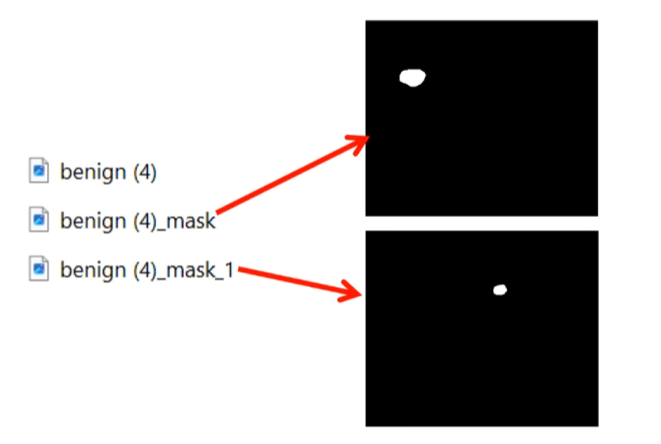

We therefore need to combine these multiple masks into one.

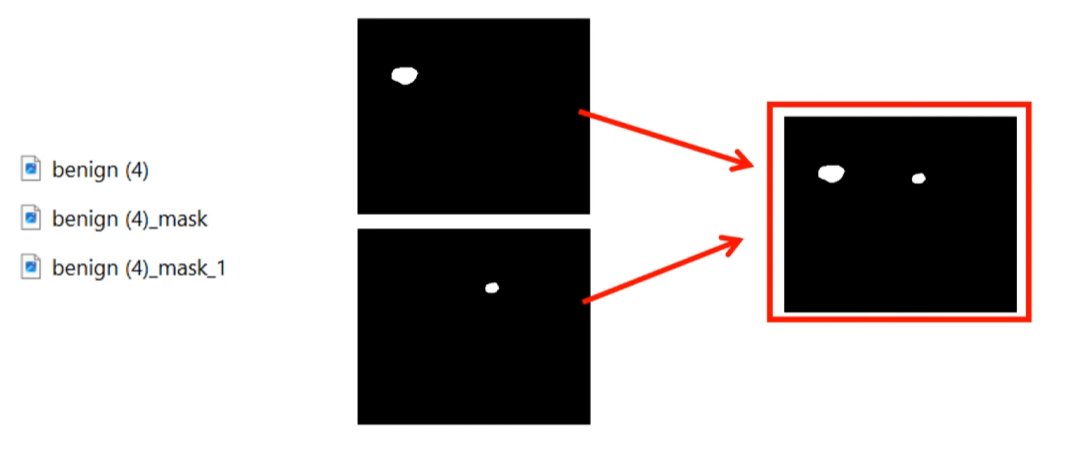
  


# IMPORTS

In [12]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

In [13]:
import tensorflow as tf

Input = tf.keras.layers.Input
Conv2D = tf.keras.layers.Conv2D
MaxPooling2D = tf.keras.layers.MaxPooling2D
Conv2DTranspose = tf.keras.layers.Conv2DTranspose
concatenate = tf.keras.layers.concatenate
Model = tf.keras.models.Model

# FOLDER PATHS

We need to reshape images to a squared size with only one channel to reduce the time for training.


I will use an input size 128 x128

A larger input size increases the computopnal cost but can give better predictions.

In [14]:
folder_paths = ["/content/dataset/malignant", "/content/dataset/benign"]

# DATA PROCESSING

> Add blockquote



In [15]:
size = 128
images = [] # Empty list to store the oryginal images in
masks = [] # Empty list to store the masks in

This piece of code combine the multiple ground truth images for the same image.

Note:

The pixel values in an image span between 0 and 255. For training neural networks, it is the best to normalize these values ( here normalize by simply dividing them by 255, which means that pixel values will now span between zero and one)

In [16]:
found_mask = False # This flag helps us handle multiple masks for the same image
# Loop through both folders
for folder_path in folder_paths:
    # Loop through all files in the current folder (sorted for consistency)
    for file_path in sorted(glob(folder_path + "/*")):
        # Load and resize the image
        img = cv2.imread(file_path)
        img = cv2.resize(img, (size, size)) # Resize image to 128×128
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Convert RGB to grayscale
        img = img / 255.0 # Normalize to [0,1]

        if "mask" in file_path: # Checks if the filename contains "mask"
            if found_mask:
                # Combine with the previous mask
                masks[-1] += img
                # Ensure binary output (0 or 1)
                masks[-1] = np.where(masks[-1] > 0.5, 1.0, 0.0)
            else:
                masks.append(img) # Adds the first mask to the list
                found_mask = True
        else:
            images.append(img) # Adds original image to the list
            found_mask = False

In [17]:
# Convert lists to NumPy arrays
X = np.array(images) # Create an array of all original images
y = np.array(masks) # Create an array of all masked imaged (Ground truth)

In [18]:
# Add a new axis as the last dimension of the arrays
X = np.expand_dims(X, -1)
y = np.expand_dims(y, -1)

X: 647 oryginal images, size 128 x 128 , 1 channel

y: 647 masks, size 128 x 128 , 1 channel

In [19]:
print(f"X shape: {X.shape} | y shape: {y.shape}")

X shape: (647, 128, 128, 1) | y shape: (647, 128, 128, 1)


SPLIT DATASET INTO 90% TRAINING 10% VALIDATION DATA.

The network will optimize its weights using the training images and will be validated on the validation dataset.

In [20]:
# Split images into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1)

# U-NET

In [21]:
# Build the U-Net
input_layer = Input(shape=(size, size, 1))
conv1 = Conv2D(64, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(input_layer)
conv1 = Conv2D(64, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv1)
pool1 = MaxPooling2D((2, 2))(conv1)

# Second encoder block
conv2 = Conv2D(128, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(pool1)
conv2 = Conv2D(128, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv2)
pool2 = MaxPooling2D((2, 2))(conv2)

# Third encoder block
conv3 = Conv2D(256, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(pool2)
conv3 = Conv2D(256, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv3)
pool3 = MaxPooling2D((2, 2))(conv3)

# Fourth encoder block
conv4 = Conv2D(512, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(pool3)
conv4 = Conv2D(512, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv4)
pool4 = MaxPooling2D((2, 2))(conv4)

# --- Bottleneck ---
bottleneck = Conv2D(1024, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(pool4)
bottleneck = Conv2D(1024, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(bottleneck)

# First decoder block
upconv1 = Conv2DTranspose(512, (2, 2), strides=2, padding="same",kernel_initializer="he_normal")(bottleneck)
concat1 = concatenate([upconv1, conv4]) # concate corresponding feature mapsS
conv5 = Conv2D(512, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(concat1)
conv5 = Conv2D(512, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv5)

# Second decoder block
upconv2 = Conv2DTranspose(256, (2, 2), strides=2, padding="same",kernel_initializer="he_normal")(conv5)
concat2 = concatenate([upconv2, conv3])
conv6 = Conv2D(256, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(concat2)
conv6 = Conv2D(256, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv6)

# Third decoder block
upconv3 = Conv2DTranspose(128, (2, 2), strides=2, padding="same",kernel_initializer="he_normal")(conv6)
concat3 = concatenate([upconv3, conv2])
conv7 = Conv2D(128, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(concat3)
conv7 = Conv2D(128, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv7)

# Fourth decoder block
upconv4 = Conv2DTranspose(64, (2, 2), strides=2, padding="same",kernel_initializer="he_normal")(conv7)
concat4 = concatenate([upconv4, conv1])
conv8 = Conv2D(64, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(concat4)
conv8 = Conv2D(64, (3, 3), activation="relu", padding="same",kernel_initializer="he_normal")(conv8)

# --- Output layer ---
output_layer = Conv2D(1, (1, 1), activation="sigmoid", padding="same")(conv8)


Param - amount of weights

last convolution involves 65 weights, because we use a 1 by 1 filter with a depth of 64 plus a bias weight.

In total, the network has about 31 million weights that will be optimized during the training.

In [22]:
# --- Model creation ---
model = Model(inputs=input_layer, outputs=output_layer)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 128, 128, 64)      │             640 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 64)      │          36,928 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 64, 64, 64)        │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 128)       │          73,856 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 64, 64, 128)       │         147,584 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 32, 32, 128)       │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 32, 32, 256)       │         295,168 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 32, 32, 256)       │         590,080 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 16, 16, 256)       │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 16, 16, 512)       │       1,180,160 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 16, 16, 512)       │       2,359,808 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_3               │ (None, 8, 8, 512)         │               0 │ conv2d_7[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 8, 8, 1024)        │       4,719,616 │ max_pooling2d_3[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 8, 8, 1024)        │       9,438,208 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 16, 16, 512)       │       2,097,66

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

Compile model

In [23]:
# Compile and train the model
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])
model.fit(X_train, y_train, epochs = 40, validation_data = (X_val,y_val),verbose=1)

Epoch 1/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.8798 - loss: 11.7497 - val_accuracy: 0.9075 - val_loss: 0.3431
Epoch 2/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8990 - loss: 0.3924 - val_accuracy: 0.9075 - val_loss: 0.3315
Epoch 3/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.9038 - loss: 0.3373 - val_accuracy: 0.9074 - val_loss: 0.3244
Epoch 4/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.9040 - loss: 0.3253 - val_accuracy: 0.9074 - val_loss: 0.3064
Epoch 5/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8935 - loss: 0.3309 - val_accuracy: 0.9074 - val_loss: 0.3002
Epoch 6/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.9040 - loss: 0.3061 - val_accuracy: 0.9074 - val_loss: 0.2751
Epoch 7/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9002 - loss: 0.2840 - val_accuracy: 0.9074 - val_loss: 0.2647
Epoch 8/40
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9040 - loss: 0.2563 - val_accuracy: 0.9074 - val_loss

# Intersection over Union score

When the treining is done we can compute the Intersection over union score (jaccard score) with the following function.
Where we used to trained U-Net to copmute the predict mask beased on the original images in the validation data.

Note

A separate test set should be used to ensure an unbiased estimate of the model’s performance. (test dataset)

!!!
However, since no separate test dataset is available, the metric is computed using the validation dataset.

In [24]:
# Compute IoU
from sklearn.metrics import jaccard_score

# Compute predicted mask
pred=model.predict(X_val,verbose=1)
pred = (pred > 0.5).astype(int) # binarize
y_true = y_val.astype(int)
# Compute IoU based on flatten predictions and ground truths
iou = jaccard_score(pred.flatten(), y_true.flatten())
print(f" IoU (Jaccard Score): {iou:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step
 IoU (Jaccard Score): 0.5732


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


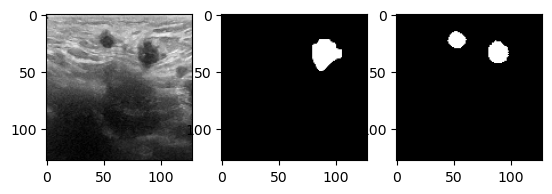

In [25]:
# Plot
i=20 # Try other values
plt.subplot(1, 3, 1)
plt.imshow(X_val[i],cmap="gray")
plt.subplot(1, 3, 2)
plt.imshow(y_val[i],cmap="gray")
plt.subplot(1, 3, 3)
pred=model.predict(np.expand_dims(X_val[i], axis=0),verbose=1)[0]
pred = (pred > 0.5) # binarize
plt.imshow(pred,cmap="gray")

To improve model - try to optimize the hyperparameters, such as:
- input image size
- batch size
- initial weights
- type of loss function
- number of epochs

In the paper, they also suggest that the random initial weights in the filters used for convolution followed by the ReLU function should be drawn from a normal distribution with a mean of zero, and a standard deviation of the square root of two over N.

N - filter size x number of input channels from previous layers 3x3x64 = 576

This can be used in code if we initialize the weights in the filters by kernel_initializer = "he_normal".  By adding this to the code the IoU score increased around 0.1 point up after training the network for 40 epochs (as previous). This shows the importance of starting with appropriate initial random weights.



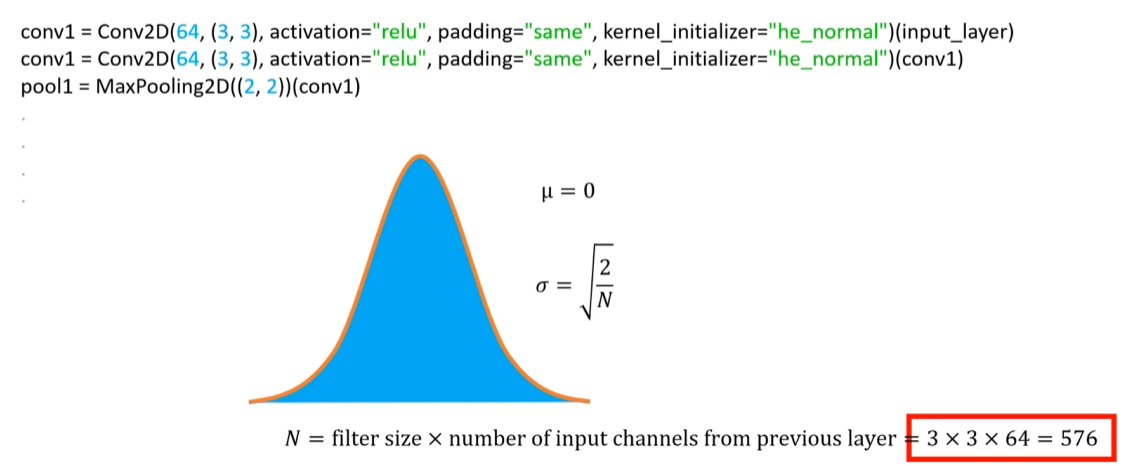

Finally, science the U-Net was published in 2015, there have been several improvements such as the integration of residual blocks and attention gates to focus the network in relevant regions.

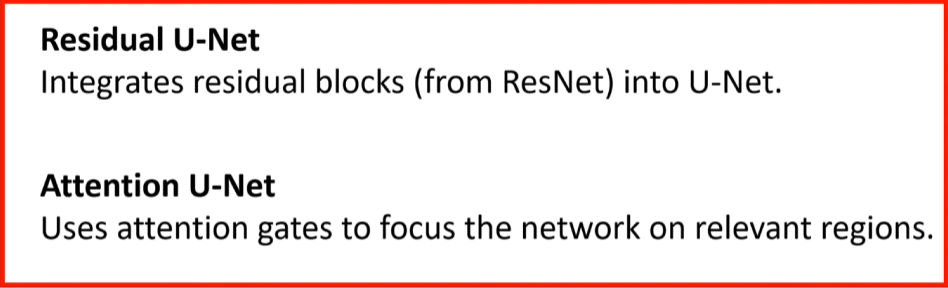